# Notebook — Teste do módulo `terrain_effects.py`

Este notebook testa o módulo:

```python
geodesy/terrain_effects.py
```

Serão testadas as funções:

- `simple_bouguer_plate`
- `residual_terrain_model`
- `rtm_gravity_effect_simple`
- `point_mass_topographic_effect`
- `prism_mass`
- `grid_topographic_point_mass_effect`

Os exemplos usam perfis e mapas sintéticos de topografia.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")
    print("Coloque este notebook no mesmo diretório da pasta geodesy/.")

import geodesy
from geodesy import terrain_effects
from geodesy import constants

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Efeito de placa de Bouguer simples


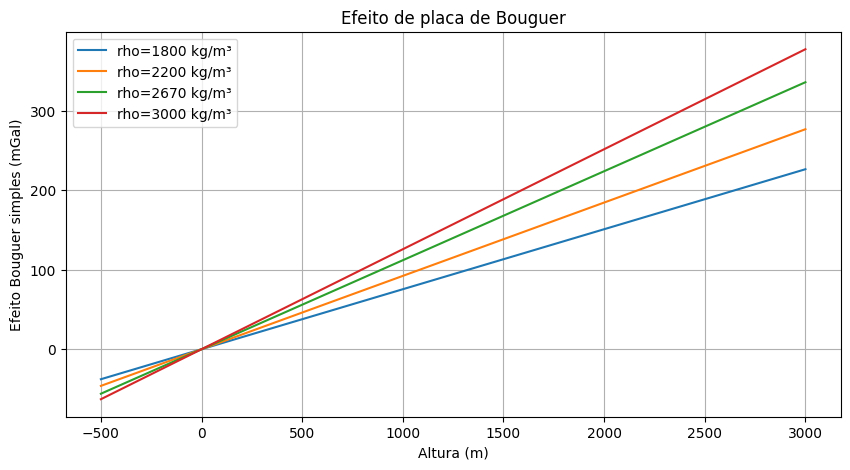

In [2]:
# ============================================================
# 1. PLACA DE BOUGUER
# ============================================================

height = np.linspace(-500, 3000, 300)

rho_values = [1800, 2200, 2670, 3000]

plt.figure(figsize=(10, 5))

for rho in rho_values:
    effect = terrain_effects.simple_bouguer_plate(height, density=rho)
    plt.plot(height, effect, label=f"rho={rho} kg/m³")

plt.xlabel("Altura (m)")
plt.ylabel("Efeito Bouguer simples (mGal)")
plt.title("Efeito de placa de Bouguer")
plt.legend()
plt.grid(True)
plt.show()


## 2. Topografia sintética e modelo residual de terreno


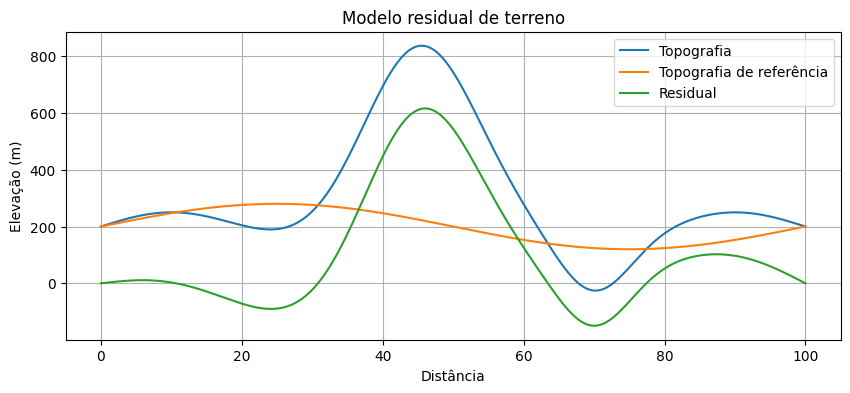

In [3]:
# ============================================================
# 2. TOPOGRAFIA RESIDUAL
# ============================================================

x = np.linspace(0, 100, 400)

topography = (
    200
    + 600*np.exp(-0.5*((x-45)/8)**2)
    - 180*np.exp(-0.5*((x-70)/5)**2)
    + 50*np.sin(2*np.pi*x/40)
)

reference_topography = (
    200
    + 80*np.sin(2*np.pi*x/100)
)

residual_topography = terrain_effects.residual_terrain_model(topography, reference_topography)

plt.figure(figsize=(10, 4))
plt.plot(x, topography, label="Topografia")
plt.plot(x, reference_topography, label="Topografia de referência")
plt.plot(x, residual_topography, label="Residual")
plt.xlabel("Distância")
plt.ylabel("Elevação (m)")
plt.title("Modelo residual de terreno")
plt.legend()
plt.grid(True)
plt.show()


## 3. Efeito RTM simples


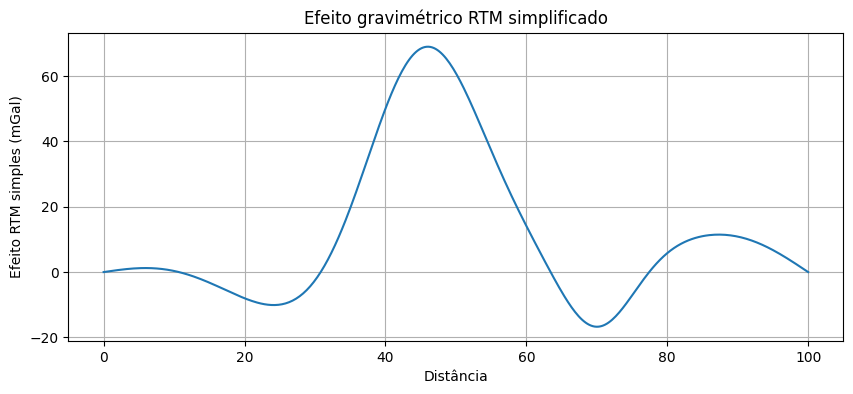

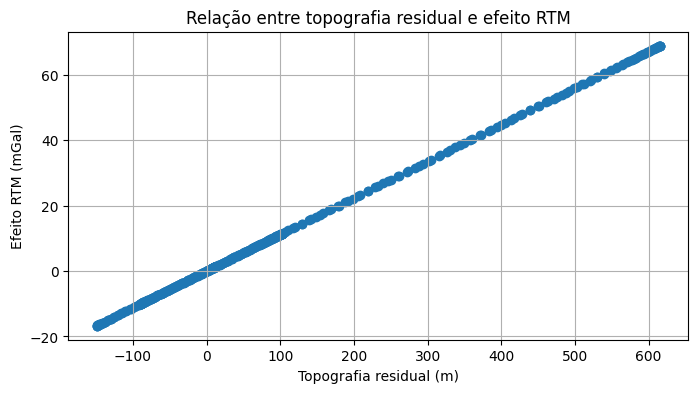

In [4]:
# ============================================================
# 3. EFEITO RTM SIMPLES
# ============================================================

rtm_effect = terrain_effects.rtm_gravity_effect_simple(
    topography,
    reference_topography,
    density=2670.0
)

plt.figure(figsize=(10, 4))
plt.plot(x, rtm_effect)
plt.xlabel("Distância")
plt.ylabel("Efeito RTM simples (mGal)")
plt.title("Efeito gravimétrico RTM simplificado")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(residual_topography, rtm_effect)
plt.xlabel("Topografia residual (m)")
plt.ylabel("Efeito RTM (mGal)")
plt.title("Relação entre topografia residual e efeito RTM")
plt.grid(True)
plt.show()


## 4. Massa de um prisma


In [5]:
# ============================================================
# 4. MASSA DE PRISMA
# ============================================================

dx = 1000.0
dy = 1000.0
dz = 500.0
rho = 2670.0

m = terrain_effects.prism_mass(dx, dy, dz, density=rho)

print("Dimensões do prisma:")
print("dx =", dx, "m")
print("dy =", dy, "m")
print("dz =", dz, "m")
print("rho =", rho, "kg/m³")
print("Massa =", m, "kg")


Dimensões do prisma:
dx = 1000.0 m
dy = 1000.0 m
dz = 500.0 m
rho = 2670.0 kg/m³
Massa = 1335000000000.0 kg


## 5. Efeito de massa pontual


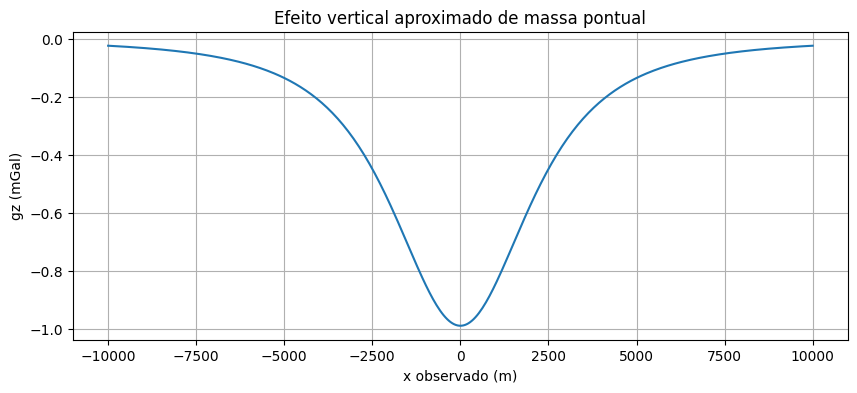

In [6]:
# ============================================================
# 5. EFEITO DE MASSA PONTUAL
# ============================================================

x_obs = np.linspace(-10000, 10000, 400)
y_obs = np.zeros_like(x_obs)
z_obs = np.zeros_like(x_obs)

x_mass = 0.0
y_mass = 0.0
z_mass = -3000.0

gz = terrain_effects.point_mass_topographic_effect(
    x_obs,
    y_obs,
    z_obs,
    x_mass,
    y_mass,
    z_mass,
    m
)

plt.figure(figsize=(10, 4))
plt.plot(x_obs, gz)
plt.xlabel("x observado (m)")
plt.ylabel("gz (mGal)")
plt.title("Efeito vertical aproximado de massa pontual")
plt.grid(True)
plt.show()


## 6. Mapa sintético de topografia e efeito local


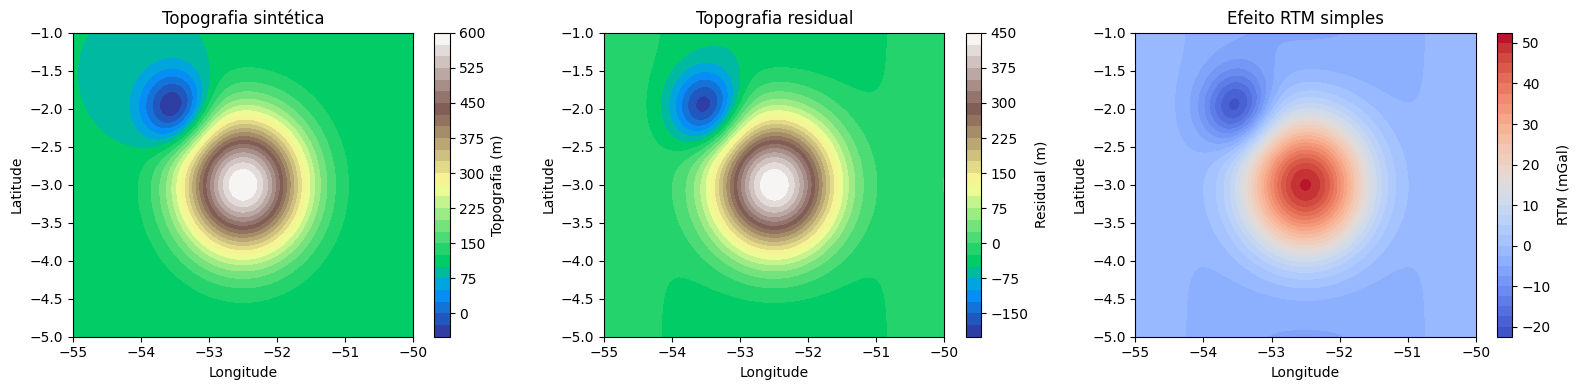

In [7]:
# ============================================================
# 6. MAPA SINTÉTICO DE TOPOGRAFIA
# ============================================================

lon = np.linspace(-55, -50, 120)
lat = np.linspace(-5, -1, 100)

LON, LAT = np.meshgrid(lon, lat)

H = (
    100
    + 500*np.exp(-((LON+52.5)**2 + (LAT+3.0)**2)/0.8)
    - 180*np.exp(-((LON+53.5)**2 + (LAT+2.0)**2)/0.25)
)

H_REF = 100 + 50*np.sin((LON + 55)*np.pi/5)

H_RES = terrain_effects.residual_terrain_model(H, H_REF)
RTM_GRID = terrain_effects.rtm_gravity_effect_simple(H, H_REF, density=2670.0)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
c1 = plt.contourf(LON, LAT, H, levels=30, cmap="terrain")
plt.colorbar(c1, label="Topografia (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Topografia sintética")

plt.subplot(1, 3, 2)
c2 = plt.contourf(LON, LAT, H_RES, levels=30, cmap="terrain")
plt.colorbar(c2, label="Residual (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Topografia residual")

plt.subplot(1, 3, 3)
c3 = plt.contourf(LON, LAT, RTM_GRID, levels=30, cmap="coolwarm")
plt.colorbar(c3, label="RTM (mGal)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Efeito RTM simples")

plt.tight_layout()
plt.show()


## 7. Efeito topográfico por massa pontual em grade


G_TOPO min/max: 2.5677992283433903e-07 12.278577168846189


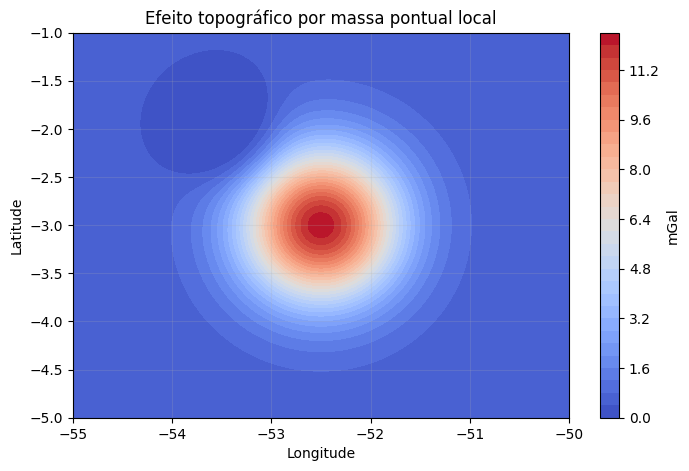

In [8]:
# ============================================================
# 7. EFEITO TOPOGRÁFICO EM GRADE
# ============================================================

cell_area = (1000.0 * 1000.0)

G_TOPO = terrain_effects.grid_topographic_point_mass_effect(
    LON,
    LAT,
    H,
    density=2670.0,
    cell_area=cell_area,
    observation_height=0.0
)

print("G_TOPO min/max:", np.nanmin(G_TOPO), np.nanmax(G_TOPO))

plt.figure(figsize=(8, 5))
c = plt.contourf(LON, LAT, G_TOPO, levels=30, cmap="coolwarm")
plt.colorbar(c, label="mGal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Efeito topográfico por massa pontual local")
plt.grid(alpha=0.2)
plt.show()


## 8. Mapas com Cartopy em Mollweide


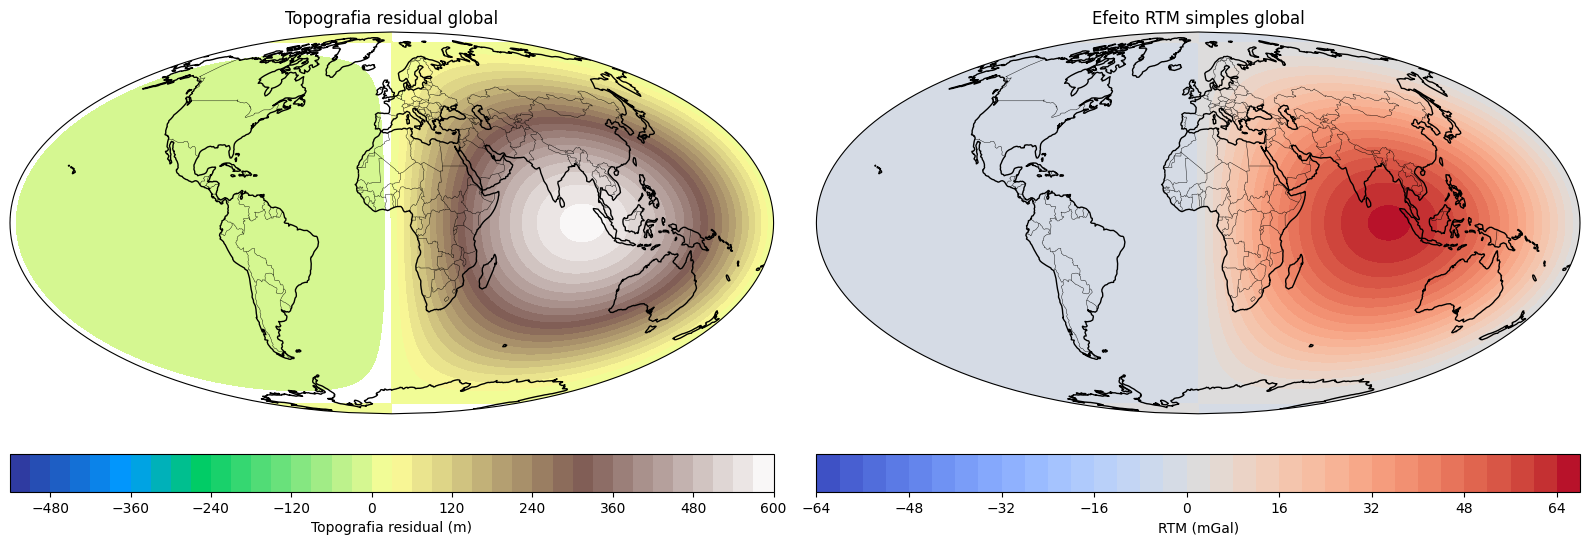

In [9]:
# ============================================================
# 8. MAPAS CARTOPY / MOLLWEIDE
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon_g = np.arange(-180.0, 180.0 + 0.5, 0.5)
lat_g = np.arange(-90.0, 90.0 + 0.5, 0.5)

LON_G, LAT_G = np.meshgrid(lon_g, lat_g)

H_G = (
    200.0
    + 700.0*np.cos(np.deg2rad(LAT_G))**2*np.sin(np.deg2rad(LON_G))
    + 350.0*np.exp(-((LON_G + 60.0)**2 + (LAT_G - 10.0)**2)/800.0)
)

H_REF_G = 200.0 + 120.0*np.sin(np.deg2rad(LON_G))*np.cos(np.deg2rad(LAT_G))
H_RES_G = terrain_effects.residual_terrain_model(H_G, H_REF_G)
RTM_G = terrain_effects.rtm_gravity_effect_simple(H_G, H_REF_G, density=2670.0)

fig = plt.figure(figsize=(16, 6))

ax1 = plt.subplot(1, 2, 1, projection=ccrs.Mollweide())
cf1 = ax1.contourf(
    LON_G, LAT_G, H_RES_G,
    levels=40,
    transform=ccrs.PlateCarree(),
    cmap="terrain"
)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
ax1.set_global()
plt.colorbar(cf1, ax=ax1, orientation="horizontal", pad=0.07, label="Topografia residual (m)")
ax1.set_title("Topografia residual global")

ax2 = plt.subplot(1, 2, 2, projection=ccrs.Mollweide())
cf2 = ax2.contourf(
    LON_G, LAT_G, RTM_G,
    levels=40,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm"
)
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
ax2.set_global()
plt.colorbar(cf2, ax=ax2, orientation="horizontal", pad=0.07, label="RTM (mGal)")
ax2.set_title("Efeito RTM simples global")

plt.tight_layout()
plt.show()

## 9. Resumo final


Se todas as células foram executadas sem erro, o módulo `terrain_effects.py` está funcionando corretamente.

Os próximos notebooks podem testar:

```python
geodesy/stokes.py
geodesy/remove_restore.py
```
